In [94]:
import warnings
warnings.filterwarnings("ignore")

import os
import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

from torchvision import datasets
from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from tqdm import tqdm

In [95]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Random Seed:", SEED)

Random Seed: 42


In [96]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 40)
print("Device :", device)

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))
    print("CUDA :", torch.version.cuda)

print("=" * 40)

Device : cuda
GPU : NVIDIA GeForce GTX 1650 Ti
CUDA : 12.8


In [97]:
TRAIN_DIR = "D:\\BrainTumorNet\\Dataset\\Testing"

TEST_DIR = "D:\\BrainTumorNet\\Dataset\\Training"

In [98]:
IMAGE_SIZE = 224

BATCH_SIZE = 32

LEARNING_RATE = 1e-4

EPOCHS = 15

NUM_CLASSES = 4

NUM_WORKERS = 4

In [99]:
classes = sorted(os.listdir(TRAIN_DIR))

print("Classes")

print(classes)

Classes
['glioma', 'meningioma', 'notumor', 'pituitary']


In [100]:
image_counts = {}

for cls in classes:

    folder = os.path.join(TRAIN_DIR, cls)

    image_counts[cls] = len(os.listdir(folder))

image_counts

{'glioma': 400, 'meningioma': 400, 'notumor': 400, 'pituitary': 400}

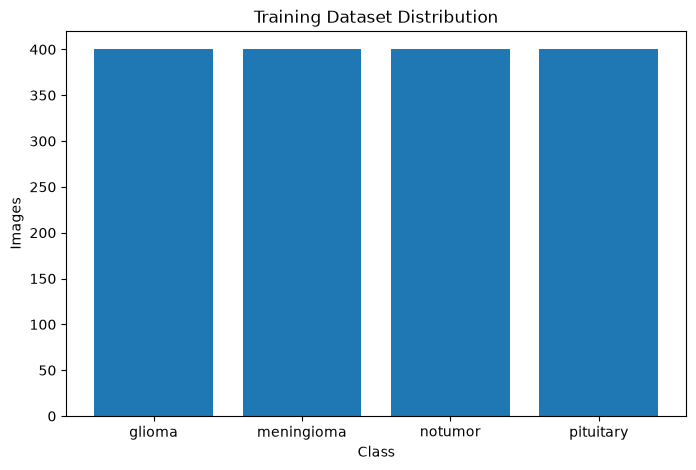

In [101]:
plt.figure(figsize=(8,5))

plt.bar(
    image_counts.keys(),
    image_counts.values()
)

plt.title("Training Dataset Distribution")

plt.xlabel("Class")

plt.ylabel("Images")

plt.show()

In [102]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [103]:
train_dataset = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=train_transform
)

test_dataset = datasets.ImageFolder(
    root=TEST_DIR,
    transform=test_transform
)

print("Training Images :", len(train_dataset))
print("Testing Images :", len(test_dataset))

Training Images : 1600
Testing Images : 5600


In [104]:
print(train_dataset.class_to_idx)

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [105]:
idx_to_class = {v: k for k, v in train_dataset.class_to_idx.items()}

print(idx_to_class)

{0: 'glioma', 1: 'meningioma', 2: 'notumor', 3: 'pituitary'}


In [106]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

In [107]:
images, labels = next(iter(train_loader))

print("Images Shape :", images.shape)
print("Labels Shape :", labels.shape)

Images Shape : torch.Size([32, 3, 224, 224])
Labels Shape : torch.Size([32])


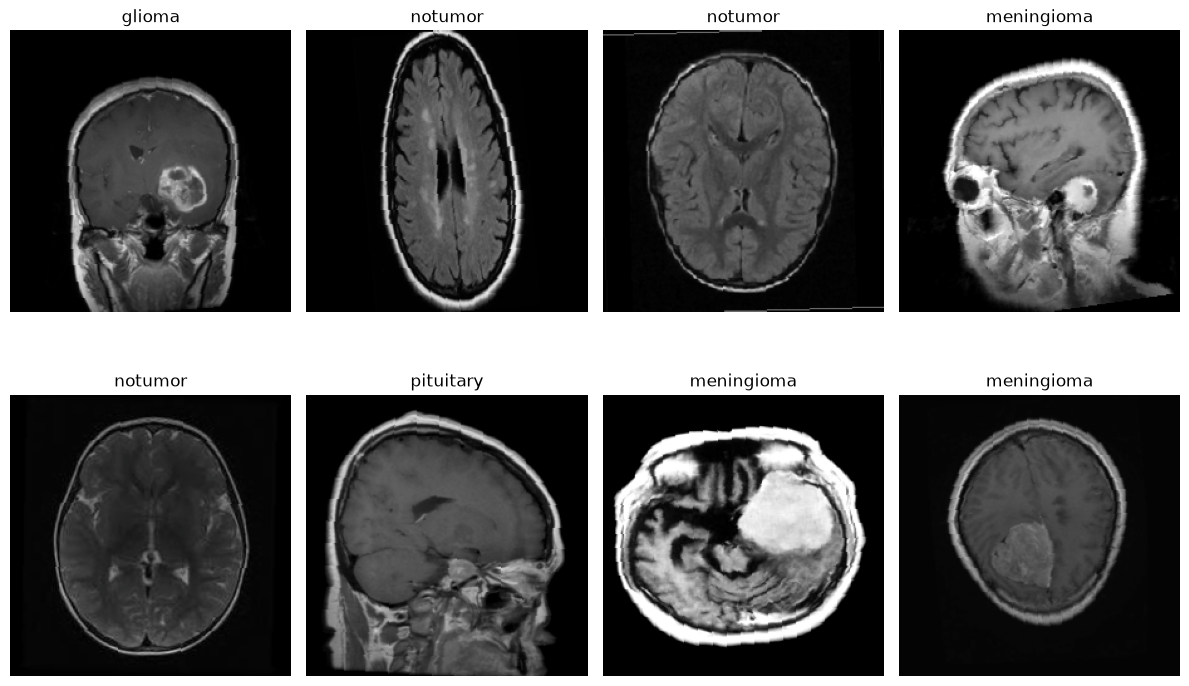

In [108]:
plt.figure(figsize=(12, 8))

for i in range(8):

    image = images[i].permute(1, 2, 0)

    image = image * torch.tensor([0.229, 0.224, 0.225]) + \
            torch.tensor([0.485, 0.456, 0.406])

    image = image.numpy()

    image = np.clip(image, 0, 1)

    plt.subplot(2, 4, i + 1)
    plt.imshow(image)
    plt.title(idx_to_class[labels[i].item()])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [109]:
print("Training Batches :", len(train_loader))
print("Testing Batches :", len(test_loader))

Training Batches : 50
Testing Batches : 175


In [110]:
print("=" * 50)

print("Classes :", train_dataset.classes)
print("Number of Classes :", len(train_dataset.classes))

print("Training Images :", len(train_dataset))
print("Testing Images :", len(test_dataset))

print("=" * 50)

Classes : ['glioma', 'meningioma', 'notumor', 'pituitary']
Number of Classes : 4
Training Images : 1600
Testing Images : 5600


In [111]:
print("Device :", device)
print("Image Size :", IMAGE_SIZE)
print("Batch Size :", BATCH_SIZE)
print("Learning Rate :", LEARNING_RATE)
print("Epochs :", EPOCHS)

print("\nEverything is ready for model training!")

Device : cuda
Image Size : 224
Batch Size : 32
Learning Rate : 0.0001
Epochs : 15

Everything is ready for model training!


In [112]:
class BrainCNN(nn.Module):

    def __init__(self, num_classes=4):
        super(BrainCNN, self).__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(256 * 14 * 14, 512),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(512, num_classes)

        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x

In [113]:
model = BrainCNN(num_classes=NUM_CLASSES).to(device)

print(model)

BrainCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)


In [114]:
total_params = sum(p.numel() for p in model.parameters())

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total Parameters : {total_params:,}")

print(f"Trainable Parameters : {trainable_params:,}")

Total Parameters : 26,082,052
Trainable Parameters : 26,082,052


In [115]:
criterion = nn.CrossEntropyLoss()

In [116]:
optimizer = torch.optim.Adam(

    model.parameters(),

    lr=LEARNING_RATE

)

In [117]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="max",

    factor=0.5,

    patience=2

)

In [118]:
def accuracy(outputs, labels):

    _, preds = torch.max(outputs, 1)

    correct = (preds == labels).sum().item()

    return correct / len(labels)

In [119]:
images, labels = next(iter(train_loader))

images = images.to(device)

outputs = model(images)

print(outputs.shape)

torch.Size([32, 4])


In [120]:
_, preds = torch.max(outputs, 1)

print(preds[:10])

tensor([0, 3, 3, 0, 3, 0, 0, 0, 1, 1], device='cuda:0')


In [121]:
def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0
    running_correct = 0
    total = 0

    for images, labels in tqdm(loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)

        running_correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(loader)

    epoch_acc = running_correct / total

    return epoch_loss, epoch_acc

In [122]:
def validate_one_epoch(model, loader, criterion, device):

    model.eval()

    running_loss = 0
    running_correct = 0
    total = 0

    predictions = []
    ground_truth = []

    with torch.no_grad():

        for images, labels in tqdm(loader):

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)

            running_correct += predicted.eq(labels).sum().item()

            predictions.extend(predicted.cpu().numpy())

            ground_truth.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader)

    epoch_acc = running_correct / total

    return epoch_loss, epoch_acc, predictions, ground_truth

In [123]:
train_losses = []

valid_losses = []

train_accuracies = []

valid_accuracies = []

In [124]:
best_accuracy = 0

In [125]:
for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    valid_loss, valid_acc, predictions, ground_truth = validate_one_epoch(
        model,
        test_loader,
        criterion,
        device
    )

    scheduler.step(valid_acc)

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    train_accuracies.append(train_acc)
    valid_accuracies.append(valid_acc)

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc:.4f}")

    print(f"Valid Loss : {valid_loss:.4f}")
    print(f"Valid Acc  : {valid_acc:.4f}")

    if valid_acc > best_accuracy:

        best_accuracy = valid_acc

        torch.save(model.state_dict(), "cnn_best.pth")

        print("Best model saved!")


Epoch 1/15


100%|██████████| 175/175 [00:51<00:00,  3.39it/s]


Train Loss : 1.5063
Train Acc  : 0.4913
Valid Loss : 0.8551
Valid Acc  : 0.5850
Best model saved!

Epoch 2/15


100%|██████████| 175/175 [00:32<00:00,  5.41it/s]


Train Loss : 0.8189
Train Acc  : 0.6637
Valid Loss : 0.6384
Valid Acc  : 0.7579
Best model saved!

Epoch 3/15


...

Train Loss : 0.3861
Train Acc  : 0.8462
Valid Loss : 0.5949
Valid Acc  : 0.8157

Epoch 14/15


100%|██████████| 175/175 [00:31<00:00,  5.64it/s]


Train Loss : 0.3612
Train Acc  : 0.8588
Valid Loss : 0.5031
Valid Acc  : 0.8298

Epoch 15/15


100%|██████████| 175/175 [00:28<00:00,  6.08it/s]

Train Loss : 0.3593
Train Acc  : 0.8612
Valid Loss : 0.4678
Valid Acc  : 0.8423


In [126]:
print(f"Best Validation Accuracy : {best_accuracy:.4f}")

Best Validation Accuracy : 0.8548


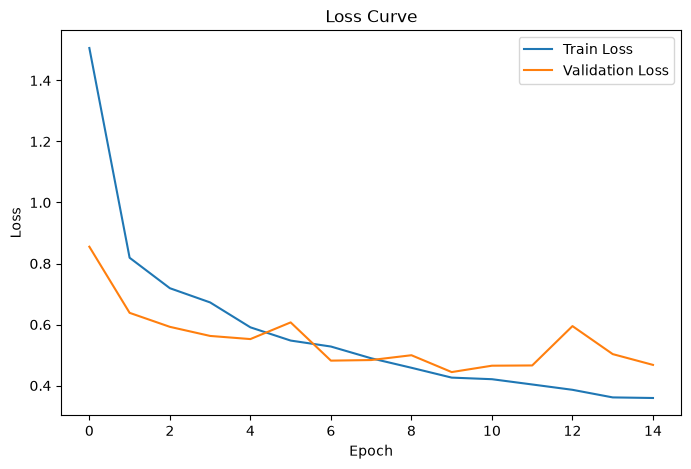

In [127]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")

plt.plot(valid_losses, label="Validation Loss")

plt.legend()

plt.title("Loss Curve")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()

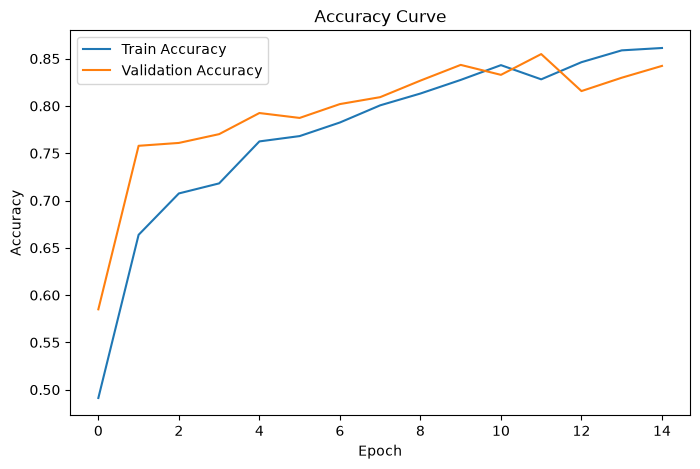

In [128]:
plt.figure(figsize=(8,5))

plt.plot(train_accuracies, label="Train Accuracy")

plt.plot(valid_accuracies, label="Validation Accuracy")

plt.legend()

plt.title("Accuracy Curve")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.show()

In [129]:
print(classification_report(
    ground_truth,
    predictions,
    target_names=train_dataset.classes
))

              precision    recall  f1-score   support

      glioma       0.95      0.71      0.81      1400
  meningioma       0.66      0.90      0.76      1400
     notumor       0.99      0.81      0.89      1400
   pituitary       0.88      0.95      0.91      1400

    accuracy                           0.84      5600
   macro avg       0.87      0.84      0.85      5600
weighted avg       0.87      0.84      0.85      5600



In [130]:
cm = confusion_matrix(ground_truth, predictions)

print(cm)

[[ 988  354    0   58]
 [  22 1260    7  111]
 [  28  222 1134   16]
 [   6   59    0 1335]]
